In [ ]:
import os

import pickle

import numpy as np
import torch
from tqdm import tqdm

from torchcodec.decoders import VideoDecoder
from transformers import AutoVideoProcessor, AutoModelForVideoClassification

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model_name = "vjepa_v2"

hf_repo = "facebook/vjepa2-vitl-fpc16-256-ssv2"
model = AutoModelForVideoClassification.from_pretrained(hf_repo).to(device).eval()
processor = AutoVideoProcessor.from_pretrained(hf_repo)


video_dir = "motion_representation/stimuli"
prefix = "processed_"

processed_videos = []

for fname in sorted(os.listdir(video_dir)):
    if not fname.startswith(prefix):
        continue

    video_path = os.path.join(video_dir, fname)
    print(f"Processing {video_path}")

    vr = VideoDecoder(video_path)

    num_frames = model.config.frames_per_clip
    frame_idx = np.linspace(0, min(len(vr), int(3 * 30)) - 1, num=num_frames, dtype=int)

    # frames: (T, H, W, C)
    video = vr.get_frames_at(indices=frame_idx).data
    video = video.permute(0, 2, 3, 1).numpy()
    processed_videos.append(video)

In [ ]:
def get_activation(model, video_batch, layer):
    layer_output = {}

    def hook_fn(_, __, output):
        layer_output["act"] = output

    hook = layer.register_forward_hook(hook_fn)

    inputs = processor(
        video_batch,  # list of (T, H, W, C)
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        model(**inputs)

    hook.remove()

    acts = layer_output["act"]
    acts = acts.detach().cpu().numpy()
    acts = acts.reshape(acts.shape[0], -1)

    return acts


modules = []
module_names = []

for name, layer in model.named_modules():
    if name.endswith("norm2"):
        modules.append(layer)
        module_names.append(name)


transformed_videos = processed_videos
batch_size = 18  # 36 / 2

pearson_RDM = {}

for layer, layer_name in tqdm(zip(modules, module_names), total=len(modules)):
    activations = []

    for block in range(0, len(transformed_videos), batch_size):
        batch_videos = transformed_videos[block : block + batch_size]

        batch_acts = get_activation(model, batch_videos, layer)
        activations.append(batch_acts)

    activations = np.vstack(activations)

    # average across category (6 categories × 6 exemplars)
    activations = activations.reshape(6, 6, -1).mean(axis=1)

    pearson_RDM[layer_name] = 1 - np.corrcoef(activations)


file_path = "result/model RDM/dynamic/pearson_RDM_vjepa_fpc16.pkl"
with open(file_path, "wb") as f:
    pickle.dump(pearson_RDM, f)

print(f"Saved RDMs to {file_path}")

/Users/nastaran/Code/motion_representation/utils/util.py:244: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/opt/homebrew/anaconda3/envs/cpc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/n_/6b_9t0zd2wq3t144k58s36_40000gn/T/ipykernel_26131/3085278877.py:211: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 1
  fig.legend(


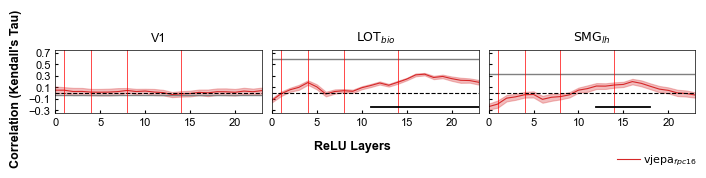

In [1]:
import itertools
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from utils.util import bootstraping, compute_noise_ceiling, filter_rsa_data, init_plot


status = "dynamic"


def load_rsa_data(region, model_name, hem):
    folder = f"result/RSA/{model_name}/pearson/{region}/"
    data = []

    if region == "behavior":
        with open(f"{folder}S02_{status}_RSA.pkl", "rb") as File:
            RSA = pickle.load(File)
        data = [[tup[1] for tup in rsa_dict.values()] for rsa_dict in RSA]
        RSA = RSA[0]
    else:
        for sub in range(1, 18):
            if sub == 1:
                continue
            if sub == 8:
                continue
            subject = f"S{sub:02d}"
            with open(f"{folder}{subject}_{hem}_{status}_RSA.pkl", "rb") as File:
                RSA = pickle.load(File)
            data.append([tup[1] for tup in RSA.values()])

    return np.array(data), RSA


def plot_significance(ax, sig, count):
    consecutive_significant_indices = {i: [] for i in range(count + 1)}
    single_significant_indices = {i: [] for i in range(count + 1)}

    for col in range(count + 1):
        significant_indices = np.where(sig[col, :])[0]
        if len(significant_indices) == 1:
            single_significant_indices[col].append(significant_indices[0])
        elif len(significant_indices) == 0:
            continue
        else:
            start = significant_indices[0]
            for i in range(1, len(significant_indices)):
                if significant_indices[i] != significant_indices[i - 1] + 1:
                    if start == significant_indices[i - 1]:
                        single_significant_indices[col].append(start)
                    else:
                        consecutive_significant_indices[col].append(
                            (start, significant_indices[i - 1])
                        )
                    start = significant_indices[i]
            if start == significant_indices[-1]:
                single_significant_indices[col].append(start)
            else:
                consecutive_significant_indices[col].append(
                    (start, significant_indices[-1])
                )

    for col in range(count + 1):
        for start_idx, end_idx in consecutive_significant_indices[col]:
            ax.plot(
                np.arange(start_idx, end_idx + 1),
                np.zeros((end_idx - start_idx + 1)) + col - 0.25,
                color="black",
                lw=1.3,
            )
        for idx in single_significant_indices[col]:
            ax.scatter(
                idx, col - 0.25, color="black", facecolor="black", s=0.5, marker="o"
            )


def main(color, condition):
    hemm = "all"

    row = len(condition)
    column = len(ROIList)
    fig, axes = plt.subplots(
        row,
        column,
        figsize=(7, 1.3 * row),
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    roi = ROIList.copy()

    handles = []
    for m, conds in enumerate(condition):
        for r, region in enumerate(ROIList):
            ax = axes[m, r]
            ax.set_axisbelow(True)
            ax.grid(False)
            ttest_data = []

            if "SMG" in region:
                region, hem = region.split("_")
                roi[r] = rf"${{\text{{{region}}}}}_{{{hem}}}$"
            else:
                hem = hemm

            if region == "MTSTS":
                roi[r] = "${\\text{LOT}}_{bio}$"

            for c, cond in enumerate(conds):
                if cond in ["S_wx", "F_wx"]:
                    model_name = "slowfast_r50"
                elif cond == "S_nox":
                    model_name = "slow_r50"
                elif cond == "S_1":
                    model_name = "res_r50"
                else:
                    model_name = cond
                data, RSA = load_rsa_data(region, model_name, hem)
                filtered_list = filter_rsa_data(RSA, cond)

                indices = [
                    i for i, key in enumerate(RSA.keys()) if key in filtered_list
                ]

                filtered_data = data[:, indices]
                ttest_data.append(filtered_data)
                SEM = stats.sem(filtered_data, axis=0)
                filtered_data = np.mean(filtered_data, axis=0)

                if cond == conds[0]:
                    nc_avg, nc_sem = compute_noise_ceiling(region, hem)
                    # ax.fill_between(
                    #     range(len(filtered_data)),
                    #     nc_avg - nc_sem,
                    #     nc_avg + nc_sem,
                    #     color="gray",
                    #     alpha=0.2,
                    # )
                    ax.plot(
                        range(len(filtered_data)),
                        np.ones((len(filtered_data))) * nc_avg,
                        color="gray",
                        lw=1,
                    )
                    # ax.plot(
                    #     range(len(filtered_data)),
                    #     np.ones((len(filtered_data))) * (nc_avg - nc_sem),
                    #     color="gray",
                    #     lw=0.2,
                    # )
                    # ax.plot(
                    #     range(len(filtered_data)),
                    #     np.ones((len(filtered_data))) * (nc_avg + nc_sem),
                    #     color="gray",
                    #     lw=0.2,
                    # )

                ax.fill_between(
                    range(len(filtered_data)),
                    filtered_data - SEM,
                    filtered_data + SEM,
                    color=color[m][c],
                    alpha=0.3,
                    lw=0.8,
                )

                ax.plot(filtered_data, color=color[m][c], label=f"{cond}", lw=0.8)

            for spine in ax.spines.values():
                spine.set_linewidth(0.5)

            ax.axhline(y=0, color="black", lw=0.8, ls="--")
            ax.tick_params(axis="x", direction="in", length=2)
            ax.tick_params(axis="y", direction="in", length=2)

            if m == 0:
                ax.set_title(f"{roi[r]}")
                for fusion in [1, 4, 8, 14]:
                    ax.axvline(x=fusion, color="red", lw=0.5)
            else:
                ax.set_xticks(range(0, len(filtered_data), 2))

            ax.set_ylim(-0.35, 0.75)
            ax.set_yticks(np.arange(-0.3, 0.75, 0.2))
            ax.set_xlim(0, len(filtered_data) - 1)

            if model_name != "dorsalnet":
                combinations = list(itertools.combinations(range(len(conds)), 2))
                if not combinations:
                    combinations = [0]
                sig = np.zeros((len(combinations), len(filtered_data)))
                for count, ind in enumerate(combinations):
                    if isinstance(ind, tuple):
                        sig[count, :] = bootstraping(
                            ttest_data[ind[0]], ttest_data[ind[1]]
                        )
                    else:
                        sig[count, :] = bootstraping(ttest_data[ind])
                plot_significance(ax, sig, count)

            latex_conditions = [
                r"${\text{" + c.replace("_", r"}}_{") + r"}$" if "_" in c else c
                for group in condition
                for c in group
            ]
            h, _ = ax.get_legend_handles_labels()
            handles.extend(h)

    fig.legend(
        handles=[handles[0], handles[1], handles[-1]],
        labels=latex_conditions,
        ncols=3,
        loc="lower right",
        frameon=False,
        columnspacing=0.8,
        handletextpad=0.3,
    )

    # fig.suptitle(datas, fontweight="bold")
    fig.supylabel("Correlation (Kendall's Tau)", fontweight="bold", ha="center")
    fig.supxlabel("ReLU Layers", fontweight="bold")
    plt.tight_layout(pad=0.5)
    plt.show()
    # plt.savefig("plot/fig1.png", dpi=300, bbox_inches="tight")


if __name__ == "__main__":
    init_plot()

    condition = [["vjepa_fpc16"]]
    color = [["tab:red"]]

    # condition = ["S_nox", "S_wx"]
    # color = ["tab:green", "tab:orange"]

    # condition = ["S_nox", "S_1"]
    # color = ["tab:green", "tab:red"]

    ROIList = ["V1", "MTSTS", "SMG_lh"]

    main(color, condition)

# VideoMAE

In [ ]:
import torch
import os
import pickle
import numpy as np
from tqdm import tqdm

from torchcodec.decoders import VideoDecoder
from transformers import AutoVideoProcessor, AutoModelForVideoClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_name = "videomae"

hf_repo = "MCG-NJU/videomae-large-finetuned-kinetics"

model = AutoModelForVideoClassification.from_pretrained(hf_repo).to(device).eval()

processor = AutoVideoProcessor.from_pretrained(hf_repo)

In [ ]:
video_dir = "motion_representation/stimuli"
prefix = "processed_"

processed_videos = []

num_frames = model.config.num_frames
sampling_rate = 2  # matches training


for fname in sorted(os.listdir(video_dir)):
    if not fname.startswith(prefix):
        continue

    video_path = os.path.join(video_dir, fname)
    print(f"Processing {video_path}")

    vr = VideoDecoder(video_path)

    num_frames = model.config.num_frames
    # frame_idx = np.linspace(0, min(len(vr), int(3 * 30)) - 1, num=num_frames, dtype=int)
    frame_idx = np.arange(0, num_frames * sampling_rate, sampling_rate)

    video = vr.get_frames_at(indices=frame_idx).data
    video = video.permute(0, 2, 3, 1).numpy()  # (T, H, W, C)

    processed_videos.append(video)

In [ ]:
def get_activation(model, video_batch, layer):
    layer_output = {}

    def hook_fn(_, __, output):
        layer_output["act"] = output

    hook = layer.register_forward_hook(hook_fn)

    inputs = processor(
        video_batch,  # list of (T, H, W, C)
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        model(**inputs)

    hook.remove()

    acts = layer_output["act"]
    acts = acts.detach().cpu().numpy()
    acts = acts.reshape(acts.shape[0], -1)

    return acts

In [ ]:
modules = []
module_names = []

for name, layer in model.named_modules():
    if name.startswith("videomae.encoder.layer") and name.endswith("layernorm_after"):
        modules.append(layer)
        module_names.append(name)

print(f"Found {len(modules)} VideoMAE layernorm_after layers")

In [ ]:
batch_size = 18
pearson_RDM = {}

for layer, layer_name in tqdm(zip(modules, module_names), total=len(modules)):
    activations = []

    for block in range(0, len(processed_videos), batch_size):
        batch_videos = processed_videos[block : block + batch_size]

        batch_acts = get_activation(model, batch_videos, layer)
        activations.append(batch_acts)

    activations = np.vstack(activations)

    # 6 categories × 6 exemplars
    activations = activations.reshape(6, 6, -1).mean(axis=1)

    pearson_RDM[layer_name] = 1 - np.corrcoef(activations)

file_path = "result/model RDM/dynamic/pearson_RDM_videomae.pkl"

with open(file_path, "wb") as f:
    pickle.dump(pearson_RDM, f)

print(f"Saved RDMs to {file_path}")

/Users/nastaran/Code/motion_representation/utils/util.py:244: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/Users/nastaran/Code/motion_representation/utils/util.py:244: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/n_/6b_9t0zd2wq3t144k58s36_40000gn/T/ipykernel_16166/64745526.py:211: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 1
  fig.legend(


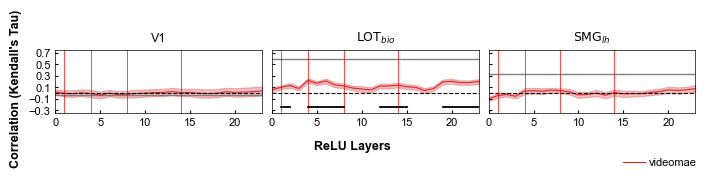

In [12]:
import itertools
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from utils.util import bootstraping, compute_noise_ceiling, filter_rsa_data, init_plot


status = "dynamic"


def load_rsa_data(region, model_name, hem):
    folder = f"result/RSA/{model_name}/pearson/{region}/"
    data = []

    if region == "behavior":
        with open(f"{folder}S02_{status}_RSA.pkl", "rb") as File:
            RSA = pickle.load(File)
        data = [[tup[1] for tup in rsa_dict.values()] for rsa_dict in RSA]
        RSA = RSA[0]
    else:
        for sub in range(1, 18):
            if sub == 1:
                continue
            if sub == 8:
                continue
            subject = f"S{sub:02d}"
            with open(f"{folder}{subject}_{hem}_{status}_RSA.pkl", "rb") as File:
                RSA = pickle.load(File)
            data.append([tup[1] for tup in RSA.values()])

    return np.array(data), RSA


def plot_significance(ax, sig, count):
    consecutive_significant_indices = {i: [] for i in range(count + 1)}
    single_significant_indices = {i: [] for i in range(count + 1)}

    for col in range(count + 1):
        significant_indices = np.where(sig[col, :])[0]
        if len(significant_indices) == 1:
            single_significant_indices[col].append(significant_indices[0])
        elif len(significant_indices) == 0:
            continue
        else:
            start = significant_indices[0]
            for i in range(1, len(significant_indices)):
                if significant_indices[i] != significant_indices[i - 1] + 1:
                    if start == significant_indices[i - 1]:
                        single_significant_indices[col].append(start)
                    else:
                        consecutive_significant_indices[col].append(
                            (start, significant_indices[i - 1])
                        )
                    start = significant_indices[i]
            if start == significant_indices[-1]:
                single_significant_indices[col].append(start)
            else:
                consecutive_significant_indices[col].append(
                    (start, significant_indices[-1])
                )

    for col in range(count + 1):
        for start_idx, end_idx in consecutive_significant_indices[col]:
            ax.plot(
                np.arange(start_idx, end_idx + 1),
                np.zeros((end_idx - start_idx + 1)) + col - 0.25,
                color="black",
                lw=1.3,
            )
        for idx in single_significant_indices[col]:
            ax.scatter(
                idx, col - 0.25, color="black", facecolor="black", s=0.5, marker="o"
            )


def main(color, condition):
    hemm = "all"

    row = len(condition)
    column = len(ROIList)
    fig, axes = plt.subplots(
        row,
        column,
        figsize=(7, 1.3 * row),
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    roi = ROIList.copy()

    handles = []
    for m, conds in enumerate(condition):
        for r, region in enumerate(ROIList):
            ax = axes[m, r]
            ax.set_axisbelow(True)
            ax.grid(False)
            ttest_data = []

            if "SMG" in region:
                region, hem = region.split("_")
                roi[r] = rf"${{\text{{{region}}}}}_{{{hem}}}$"
            else:
                hem = hemm

            if region == "MTSTS":
                roi[r] = "${\\text{LOT}}_{bio}$"

            for c, cond in enumerate(conds):
                if cond in ["S_wx", "F_wx"]:
                    model_name = "slowfast_r50"
                elif cond == "S_nox":
                    model_name = "slow_r50"
                elif cond == "S_1":
                    model_name = "res_r50"
                else:
                    model_name = conds[0]
                data, RSA = load_rsa_data(region, model_name, hem)
                filtered_list = filter_rsa_data(RSA, cond)

                indices = [
                    i for i, key in enumerate(RSA.keys()) if key in filtered_list
                ]

                filtered_data = data[:, indices]
                ttest_data.append(filtered_data)
                SEM = stats.sem(filtered_data, axis=0)
                filtered_data = np.mean(filtered_data, axis=0)

                if cond == conds[0]:
                    nc_avg, nc_sem = compute_noise_ceiling(region, hem)
                    # ax.fill_between(
                    #     range(len(filtered_data)),
                    #     nc_avg - nc_sem,
                    #     nc_avg + nc_sem,
                    #     color="gray",
                    #     alpha=0.2,
                    # )
                    ax.plot(
                        range(len(filtered_data)),
                        np.ones((len(filtered_data))) * nc_avg,
                        color="gray",
                        lw=1,
                    )
                    # ax.plot(
                    #     range(len(filtered_data)),
                    #     np.ones((len(filtered_data))) * (nc_avg - nc_sem),
                    #     color="gray",
                    #     lw=0.2,
                    # )
                    # ax.plot(
                    #     range(len(filtered_data)),
                    #     np.ones((len(filtered_data))) * (nc_avg + nc_sem),
                    #     color="gray",
                    #     lw=0.2,
                    # )

                ax.fill_between(
                    range(len(filtered_data)),
                    filtered_data - SEM,
                    filtered_data + SEM,
                    color=color[m][c],
                    alpha=0.3,
                    lw=0.8,
                )

                ax.plot(filtered_data, color=color[m][c], label=f"{cond}", lw=0.8)

            for spine in ax.spines.values():
                spine.set_linewidth(0.5)

            ax.axhline(y=0, color="black", lw=0.8, ls="--")
            ax.tick_params(axis="x", direction="in", length=2)
            ax.tick_params(axis="y", direction="in", length=2)

            if m == 0:
                ax.set_title(f"{roi[r]}")
                for fusion in [1, 4, 8, 14]:
                    ax.axvline(x=fusion, color="red", lw=0.5)
            else:
                ax.set_xticks(range(0, len(filtered_data), 2))

            ax.set_ylim(-0.35, 0.75)
            ax.set_yticks(np.arange(-0.3, 0.75, 0.2))
            ax.set_xlim(0, len(filtered_data) - 1)

            if model_name != "dorsalnet":
                combinations = list(itertools.combinations(range(len(conds)), 2))
                if not combinations:
                    combinations = [0]
                sig = np.zeros((len(combinations), len(filtered_data)))
                for count, ind in enumerate(combinations):
                    if isinstance(ind, tuple):
                        sig[count, :] = bootstraping(
                            ttest_data[ind[0]], ttest_data[ind[1]]
                        )
                    else:
                        sig[count, :] = bootstraping(ttest_data[ind])
                plot_significance(ax, sig, count)

            latex_conditions = [
                r"${\text{" + c.replace("_", r"}}_{") + r"}$" if "_" in c else c
                for group in condition
                for c in group
            ]
            h, _ = ax.get_legend_handles_labels()
            handles.extend(h)

    fig.legend(
        handles=[handles[0], handles[1], handles[-1]],
        labels=latex_conditions,
        ncols=3,
        loc="lower right",
        frameon=False,
        columnspacing=0.8,
        handletextpad=0.3,
    )

    # fig.suptitle(datas, fontweight="bold")
    fig.supylabel("Correlation (Kendall's Tau)", fontweight="bold", ha="center")
    fig.supxlabel("ReLU Layers", fontweight="bold")
    plt.tight_layout(pad=0.5)
    plt.show()
    # plt.savefig("plot/fig1.png", dpi=300, bbox_inches="tight")


if __name__ == "__main__":
    init_plot()

    condition = [["videomae"]]
    color = [["tab:red"]]

    ROIList = ["V1", "MTSTS", "SMG_lh"]

    main(color, condition)